In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/InflAdj_Data_2019_2025-20th-20th.csv")

In [77]:
# df = df.loc[~df["symbol"].isin(df.loc[(df["close"] < 5) & (df["report_date"] == df.groupby('symbol')['report_date'].transform('min'))]["symbol"]),:]

In [78]:
# df.loc[df["symbol"].isin(df.loc[(df["close"] < 4.65) & (df["report_date"] == "2019-01-02")]["symbol"]),:]["symbol"].unique()

In [ ]:
# df.to_csv("data/InflAdj_Data_2019_2025_more_than_five.csv")

In [22]:
df = df.loc[:, ["report_date", "close (%)"]].groupby("report_date").mean()

In [23]:
df.loc[df["close (%)"] < 0,:]

,close (%)
report_date,
2019-01-03,-1.057445
2020-03-09,-4.344127
2020-03-10,-2.150726
2020-03-11,-7.266728
2020-03-12,-17.143065
...,...
2025-05-08,-2.054362
2025-05-09,-2.003395
2025-05-21,-0.153125


Line will not start in the centre, because then we can't do negative values, instead start a set distance from the centre, probably one so that we avoid negative values from crossing the centre

In [24]:
df.reset_index(inplace=True)

In [25]:
df["report_date"] = pd.to_datetime(df["report_date"])
df

,report_date,close (%)
0,2019-01-02,0.000000
1,2019-01-03,-1.057445
2,2019-01-04,1.996026
3,2019-01-07,3.524115
4,2019-01-08,4.649826
...,...,...
1755,2025-12-24,13.823307
1756,2025-12-26,13.722539
1757,2025-12-29,13.093518
1758,2025-12-30,12.781311


In [26]:
df['month'] = pd.DatetimeIndex(df['report_date']).month
df["day"] = pd.DatetimeIndex(df['report_date']).day

In [27]:
month_to_degree = {m: (m - 1) * 30 for m in range(1, 13)}
df["month_rotation"] = df["month"].map(month_to_degree.get)

In [28]:
# 2. Convert report_date to datetime if not already
df['report_date'] = pd.to_datetime(df['report_date'])
df['year'] = df['report_date'].dt.year

# 3. Calculate min and max day for each month per year
# We group by year and month to handle the "dynamic" nature of banking days
month_bounds = df.groupby(['year', 'month'])['day'].agg(['min', 'max']).reset_index()
month_bounds.rename(columns={'min': 'min_day', 'max': 'max_day'}, inplace=True)

# 4. Merge these bounds back into the main dataframe
df = df.merge(month_bounds, on=['year', 'month'])

# 5. Calculate the rotation
# (day - min) / (max - min) gives a value between 0 and 1
# We use .fillna(0) for cases where a month might only have 1 data point
df['day_progress'] = (df['day'] - df['min_day']) / (df['max_day'] - df['min_day']).replace(0, 1)
df['day_degrees'] = df['month'].map(month_to_degree) + (df['day_progress'] * 30)

# Cleanup (optional)
df = df.drop(columns=['min_day', 'max_day', 'day_progress'])

In [29]:
shift_zero = abs(df["close (%)"].min())
df["distance_from_center"] = df["close (%)"] + shift_zero

In [30]:
from numpy import cos, sin, radians
df["x"] = df["distance_from_center"] * sin(radians(df["day_degrees"]))
df["y"] = df["distance_from_center"] * cos(radians(df["day_degrees"]))

In [32]:
df["cont_time"] = df.index

In [109]:
# plt.figure(figsize=(13,10))
# plt.scatter(df["x"], df["y"], c = df["cont_time"])
# plt.colorbar()
# plt.axis("off")

In [34]:
df

,report_date,close (%),month,day,month_rotation,year,day_degrees,distance_from_center,x,y,cont_time
0,2019-01-02,0.000000,1,2,0,2019,0.000000,27.896242,0.000000e+00,27.896242,0
1,2019-01-03,-1.057445,1,3,0,2019,1.034483,26.838797,4.845516e-01,26.834423,1
2,2019-01-04,1.996026,1,4,0,2019,2.068966,29.892268,1.079183e+00,29.872781,2
3,2019-01-07,3.524115,1,7,0,2019,5.172414,31.420356,2.832642e+00,31.292410,3
4,2019-01-08,4.649826,1,8,0,2019,6.206897,32.546068,3.518849e+00,32.355282,4
...,...,...,...,...,...,...,...,...,...,...,...
1755,2025-12-24,13.823307,12,24,330,2025,353.000000,41.719549,-5.084334e+00,41.408577,1755
1756,2025-12-26,13.722539,12,26,330,2025,355.000000,41.618781,-3.627316e+00,41.460409,1756
1757,2025-12-29,13.093518,12,29,330,2025,358.000000,40.989759,-1.430522e+00,40.964790,1757
1758,2025-12-30,12.781311,12,30,330,2025,359.000000,40.677553,-7.099212e-01,40.671358,1758


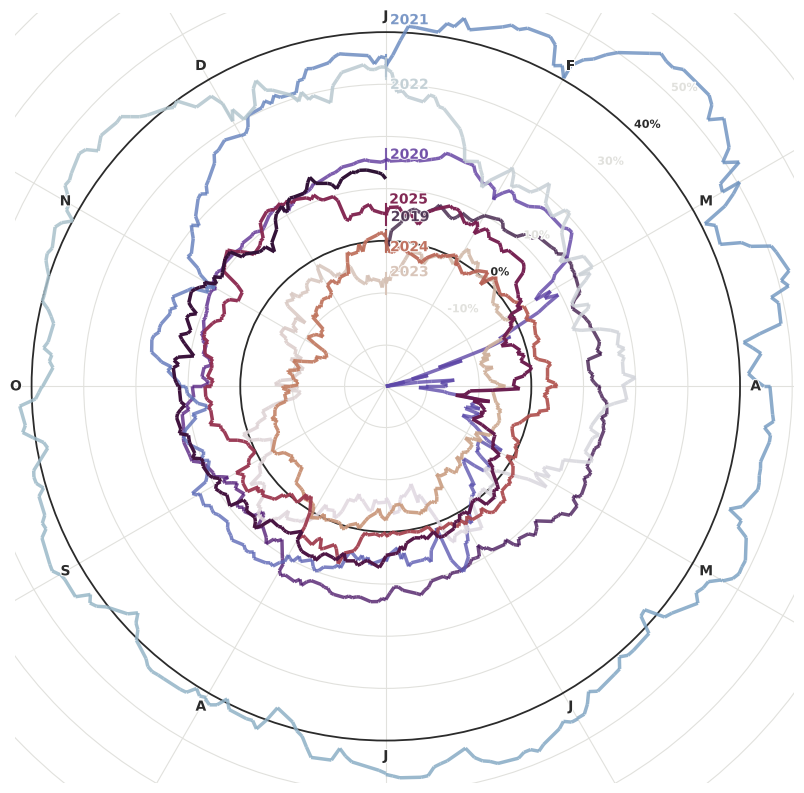

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from adjustText import adjust_text
import matplotlib.patheffects as path_effects

minor_line_settings = ("#E1E1DD", 0.8, 1, "-") # color, linewidth, alpha, style
major_line_settings = ("#2b2b2b", 1.3, 1, "-") # color, linewidth, alpha, style
data_line_settings = ("twilight_shifted", 2.5, (0.75, 1), "-") # cmap, linewidth, (alpha_min, alpha_max), style
text_outline_settings = ("white", 1.5) # color, linewidth


# 1. Generate sample data (a spiral)
x = df["x"]
y = df["y"]
z = df["cont_time"]  # The values used for coloring



# 2. Prepare the segments (reshape points into[N, 1, 2] array)
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# 2. Setup the colormap and normalization
cmap = plt.get_cmap(data_line_settings[0]) # Ensure this matches your LineCollection
norm = plt.Normalize(df['cont_time'].min(), df['cont_time'].max())

# 3. Create the LineCollection
fig, ax = plt.subplots()
fig.set_figheight(10)
fig.set_figwidth(13)

def scale_to_range(arr, new_min=0.5, new_max=1.0):
    arr = np.array(arr)
    # Calculate min and max of the input array
    old_min = arr.min()
    old_max = arr.max()
    
    # Avoid division by zero if all values are the same
    if old_max == old_min:
        return np.full_like(arr, (new_min + new_max) / 2)
    
    # Apply the formula
    return new_min + (arr - old_min) * (new_max - new_min) / (old_max - old_min)

rgba_values = cmap(norm(df['cont_time']))
rgba_values[:, 3] = scale_to_range(df['cont_time'], new_min=data_line_settings[2][0], new_max=data_line_settings[2][1])

# lc = LineCollection(segments, cmap=cmap, norm=norm)
lc = LineCollection(segments, colors=rgba_values)
# lc.set_array(z)
lc.set_linewidth(data_line_settings[1])

# 4. Add to plot
line = ax.add_collection(lc)
# fig.colorbar(line, ax=ax)
ax.set_xlim(x.min()-1, x.max()+1)
ax.set_ylim(y.min()-1, y.max()+1)


# 4. Annotate the first occurrence of each year
# Find the index of the first row for every unique year
first_year_indices = df.drop_duplicates(subset='year', keep='first').index

texts = list()

for idx in first_year_indices:
    year = df.loc[idx, 'year']
    val = df.loc[idx, 'cont_time']
    x_pos = df.loc[idx, 'x']
    x_pos_text = df.loc[idx, 'x']+1.5
    y_pos = df.loc[idx, 'y']
    y_pos_text= df.loc[idx+3, 'y']
    alpha = rgba_values[:, 3][idx]

    point_color = cmap(norm(val))

    tick_length = 4
    ax.plot([x_pos, x_pos],[y_pos - tick_length/2, y_pos + tick_length/2], 
            color=point_color, lw=1.5, zorder=10, alpha=alpha)
    
    t = ax.text(
        x_pos_text, y_pos_text, 
        str(year), 
        color=point_color,
        fontsize=10, 
        fontweight='bold',
        alpha=alpha
    )

    # Add the outline (Stroke) and the original text (Normal)
    t.set_path_effects([
        path_effects.Stroke(linewidth=text_outline_settings[1], foreground=text_outline_settings[0]),
        path_effects.Normal()
    ])
    texts.append(t)

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))


# 1. Calculate the maximum distance to determine the scale
max_dist = df['distance_from_center'].max()

angles = list(month_to_degree.values())


def rotate_vector(vector, angle_degrees):
    theta = np.radians(angle_degrees)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(((c, -s), (s, c)))
    return vector @ R.T


# 2. Define the radii for your concentric circles
# We want circles at 20%, 40%, 60%, 80%, and 100% of the maximum radius
bar_spacing_percent = 10
radii = np.arange(-round(shift_zero,-1), round(max_dist, -1), bar_spacing_percent) + shift_zero # Can be negative so change this because if negative it gets converted to positive and does a ring where we don't want it
radii = radii[radii > 0] # Remove negative radii
raddi_to_idx = {r: i for i, r in enumerate(radii)}

# Loop through each angle to plot individual lines, the "axis" lines
month_texts = []
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
ring_num = raddi_to_idx[round(df[df["x"] == 0]["y"].max(), -1) + shift_zero] - 2

for i, angle in enumerate(angles):
    # 1. Define the start (center) and end point
    start_point = np.array([0, 0])
    end_point = rotate_vector(np.array([0, radii[-1]+2]), -angle)
    
    # 2. Plot the line
    # X coordinates:[start_x, end_x], Y coordinates: [start_y, end_y]
    ax.plot([start_point[0], end_point[0]], 
            [start_point[1], end_point[1]], 
            color=minor_line_settings[0], alpha=minor_line_settings[2], lw=minor_line_settings[1], linestyle=minor_line_settings[3], zorder=0)
    
    text_point = rotate_vector(np.array([0, radii[ring_num]+3]), -angle)
    
    t = ax.text(
        text_point[0], text_point[1], 
        str(months[i]), 
        color=major_line_settings[0],
        fontsize=10, 
        fontweight='bold',
        alpha=major_line_settings[2],
        ha='center',
        va='center',
    )
    t.set_path_effects([
        path_effects.Stroke(linewidth=text_outline_settings[1], foreground=text_outline_settings[0]),
        path_effects.Normal()
    ])
    month_texts.append(t)

# Add percentage labels for the rings
for i, r in enumerate(radii[:ring_num+2]):
    x, y = rotate_vector(np.array([0, r+3]), -angles[2]+angles[1]/2) # Rotate the point on the y-axis to align with the first month line
    label = f"{int((r - shift_zero))}%"
    if (r == 0 + shift_zero) or i == ring_num: # Skip the zero point and the month ring
        t = ax.text(
        x, y, 
        label, 
        color=major_line_settings[0],
        fontsize=8, 
        fontweight='bold',
        alpha=major_line_settings[2],
        ha='center',
        va='center',
        )
    elif i % 2 == 0:
        continue
    else:
        t = ax.text(
            x, y, 
            label, 
            color=minor_line_settings[0],
            fontsize=8, 
            fontweight='bold',
            alpha=minor_line_settings[2],
            ha='center',
            va='center',
        )
    t.set_path_effects([
        path_effects.Stroke(linewidth=text_outline_settings[1], foreground=text_outline_settings[0]),
        path_effects.Normal()
    ])
    
# 3. Add circles to the plot
for i, r in enumerate(radii):
    if r == radii[ring_num]: # This is the month ring
        circle = plt.Circle(
            (0, 0),             # Center at the origin (0,0)
            r,                  # Radius
            color=major_line_settings[0],       # Color of the ring
            fill=False,         # Keep the center transparent
            linestyle=major_line_settings[3],     # Dashed line style
            linewidth=major_line_settings[1],        # Thickness of the ring
            alpha=major_line_settings[2],          # Transparency
            zorder=0            # Put behind the data line
        )
        ax.add_patch(circle)
    else: # These are the minor rings
        circle = plt.Circle(
            (0, 0),             # Center at the origin (0,0)
            r,                  # Radius
            color=minor_line_settings[0],       # Color of the ring
            fill=False,         # Keep the center transparent
            linestyle=minor_line_settings[3],     # Dashed line style
            linewidth=minor_line_settings[1],        # Thickness of the ring
            alpha=minor_line_settings[2],          # Transparency
            zorder=0            # Put behind the data line
        )
        ax.add_patch(circle)

circle = plt.Circle(            # Zero point ring
            (0, 0),             # Center at the origin (0,0)
            shift_zero,         # Radius
            color=major_line_settings[0],      # Color of the ring
            fill=False,         # Keep the center transparent
            linestyle=major_line_settings[3],      # Normal line style
            linewidth=major_line_settings[1],        # Thickness of the ring
            alpha=major_line_settings[2],          # Transparency
            zorder=0            # Put behind the data line
        )
ax.add_patch(circle)

# 5. Final adjustments
ax.autoscale_view()
ax.set_aspect('equal') # Important for spiral/radial plots
ax.axis('off') 
# ax.set_xlim(xmin=-radii[-1], xmax=radii[-1])
# ax.set_ylim(ymin=-radii[-1], ymax=radii[-1])
plt.show()


In [84]:
ring_num

6

In [36]:
fig.savefig("figs/spiral_test_2.png", dpi=300, bbox_inches="tight")
fig.savefig("figs/spiral_test_2.pdf", bbox_inches="tight")

FileNotFoundError: [Errno 2] No such file or directory: 'figs/spiral_test_2.png'